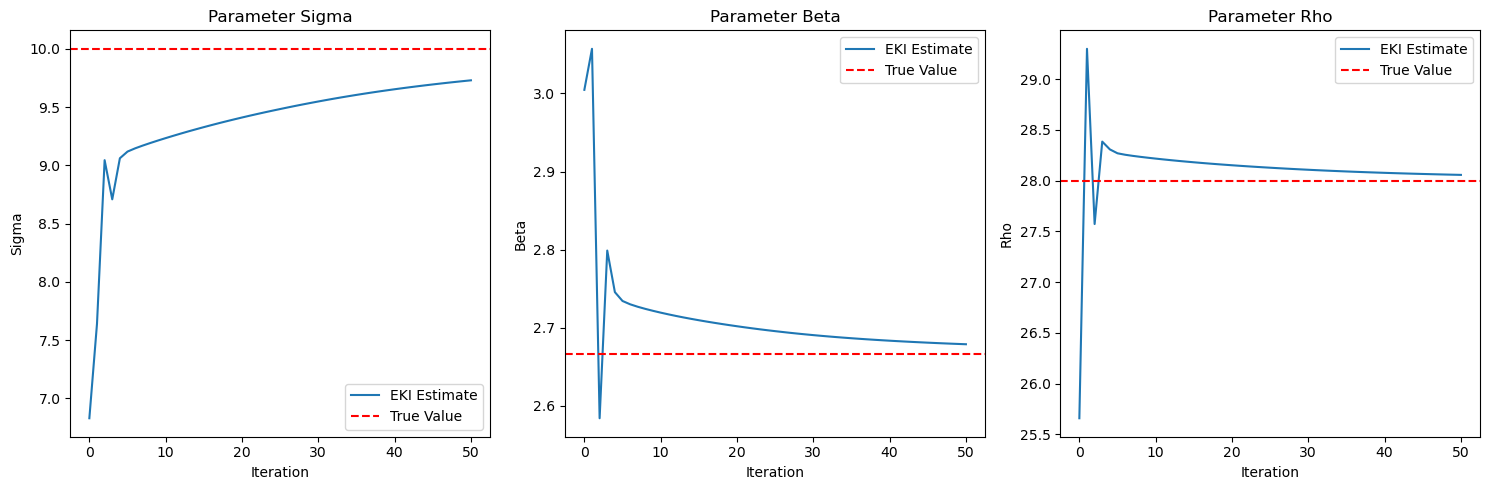

Final Parameter Estimates: [ 9.72948122  2.6788657  28.05656259]
True Parameters: [10.          2.66666667 28.        ]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --------------------------------------------------------------
# Step 1: Define the Lorenz-63 Model (Forward Operator)
# --------------------------------------------------------------
def lorenz63(t, state, sigma, beta, rho):
    """Lorenz-63 system of differential equations."""
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

def run_lorenz63(params, t_eval):
    """
    Solves the Lorenz-63 system given parameters.

    params: (sigma, beta, rho) - The parameters of the system
    t_eval: Array of time points at which to evaluate the solution
    """
    sigma, beta, rho = params
    init_state = [1.0, 1.0, 1.0]  # Initial condition
    sol = solve_ivp(lorenz63, [t_eval[0], t_eval[-1]], init_state, args=(sigma, beta, rho), t_eval=t_eval)
    return sol.y  # Return the full trajectory

# --------------------------------------------------------------
# Step 2: Generate "Truth" Data (Synthetic Observations)
# --------------------------------------------------------------
true_params = np.array([10.0, 8/3, 28.0])  # Known Lorenz-63 parameters
t_eval = np.linspace(0, 2, 100)  # 2 seconds of integration

true_trajectory = run_lorenz63(true_params, t_eval)  # Generate observations
observed_data = true_trajectory + np.random.normal(0, 0.15, true_trajectory.shape)  # Add small noise

# --------------------------------------------------------------
# Step 3: Initialize an Ensemble of Parameters
# --------------------------------------------------------------
N_ensemble = 30  # Number of ensemble members
param_dim = 3  # Number of parameters (sigma, beta, rho)

# Initial ensemble sampled from a normal distribution centered around a guess
param_ensemble = np.random.normal(loc=np.array([7, 3, 25])[:, np.newaxis], 
                                  scale=np.array([1, 0.5, 3])[:, np.newaxis], 
                                  size=(param_dim, N_ensemble))

# --------------------------------------------------------------
# Step 4: Define EKI Update Function
# --------------------------------------------------------------
def ensemble_kalman_update(param_ensemble, observed_data, t_eval, inflation=1.05):
    """
    Performs one iteration of Ensemble Kalman Inversion.

    param_ensemble: (param_dim, N_ensemble) matrix of parameter guesses
    observed_data: True observations of the system
    t_eval: Time points for integration
    inflation: Factor to increase covariance to prevent collapse
    """
    N_ensemble = param_ensemble.shape[1]  # Number of ensemble members

    # Step 1: Run the Lorenz model for each ensemble member
    model_outputs = np.array([run_lorenz63(param_ensemble[:, i], t_eval) for i in range(N_ensemble)])  # (N_ensemble, 3, 100)

    # Step 2: Compute the ensemble mean
    param_mean = np.mean(param_ensemble, axis=1)  # Mean of parameters (3,)
    model_mean = np.mean(model_outputs, axis=0)  # Mean trajectory (3, 100)

    # Step 3: Compute Covariances
    C_pY = np.zeros((param_dim, 3))  # (3,3) for parameter-to-model-output covariance
    C_YY = np.zeros((3, 3))  # (3,3) model output covariance

    for i in range(N_ensemble):
        dp = (param_ensemble[:, i] - param_mean).reshape(-1, 1)  # (3,1)
        dy = np.mean(model_outputs[i] - model_mean, axis=1).reshape(-1, 1)  # (3,1) - Mean over time

        C_pY += dp @ dy.T  # Outer product results in (3,3)
        C_YY += dy @ dy.T  # Outer product results in (3,3)

    C_pY /= (N_ensemble - 1)
    C_YY /= (N_ensemble - 1)

    # Step 4: Compute Kalman Gain
    C_YY += np.eye(3) * 1e-3  # Regularization for numerical stability
    Kalman_gain = C_pY @ np.linalg.inv(C_YY)  # (3,3)

    # Step 5: Update Parameters
    observed_mean = np.mean(observed_data, axis=1)  # (3,) - Mean over time

    for i in range(N_ensemble):
        model_mean_i = np.mean(model_outputs[i], axis=1)  # (3,) - Mean over time
        correction = Kalman_gain @ (observed_mean - model_mean_i)  # Now both are (3,)
        param_ensemble[:, i] += correction  # Update parameter vector

    # Apply covariance inflation to avoid collapse
    param_ensemble = param_mean[:, np.newaxis] + inflation * (param_ensemble - param_mean[:, np.newaxis])

    return param_ensemble

# --------------------------------------------------------------
# Step 5: Run EKI Iteratively
# --------------------------------------------------------------
num_iterations = 50
history = [param_ensemble.copy()]

for k in range(num_iterations):
    param_ensemble = ensemble_kalman_update(param_ensemble, observed_data, t_eval)
    history.append(param_ensemble.copy())

# --------------------------------------------------------------
# Step 6: Plot Results
# --------------------------------------------------------------
param_labels = ["Sigma", "Beta", "Rho"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(param_dim):
    axes[i].plot(range(num_iterations + 1), [np.mean(h[i, :]) for h in history], label="EKI Estimate")
    axes[i].axhline(true_params[i], color="red", linestyle="--", label="True Value")
    axes[i].set_title(f"Parameter {param_labels[i]}")
    axes[i].set_xlabel("Iteration")
    axes[i].set_ylabel(param_labels[i])
    axes[i].legend()

plt.tight_layout()
plt.show()

# Print final estimated parameters
final_estimates = np.mean(param_ensemble, axis=1)
print("Final Parameter Estimates:", final_estimates)
print("True Parameters:", true_params)
